In [1]:
### check wireline log inventory from force 2020 competition dataset

In [2]:
### imports
import os
from pathlib import Path

import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import random
import sys


### pygmt imports
import pyproj
proj_path = os.path.join(sys.prefix, "share", "proj")
pyproj.datadir.set_data_dir(proj_path)
from pyproj import CRS, Transformer
import pygmt

/Users/user/micromamba/envs/universal/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [22]:
### establish unit conversions

FT_PER_M = 3.28084

In [ ]:
### set project paths 

cwd = Path.cwd()
project_dir = cwd.parent
data_root_dir = project_dir.parent / "data"

def list_contents(dir):
    print(f'\nELEMENTS IN /{os.path.basename(dir)}/:')
    print(f'{sorted(path.name for path in dir.iterdir())}')

list_contents(project_dir)
list_contents(data_root_dir)

data_dir = data_root_dir / 'force_2020_well_log_analysis' / 'Force_2020_all_wells'

LAS_FILES = sorted(data_dir.glob("*.las"))
print(f"LAS files found: {len(LAS_FILES)}")

list_contents(data_dir)


ELEMENTS IN /force_2020_well_log_analysis/:
['.DS_Store', '.git', '.venv', '.vscode', 'README.md', 'notebooks']

ELEMENTS IN /data/:
['.DS_Store', 'force_2020_well_log_analysis']


In [ ]:
### get header values

def get_header_value(las, mnemonic):
    try:
        return las.well[mnemonic].value
    except (KeyError, AttributeError):
        return np.nan

well_records = []
curve_records = []

### iterate over each of 118 wells and get header values, curves and statistics

for path in LAS_FILES:
    try:
        ### get las file path
        las = lasio.read(path)
        df = las.df()

        depth = pd.to_numeric(
            pd.Series(df.index),
            errors="coerce",
        ).dropna().to_numpy()

        depth_difference = np.diff(depth)

        ### get mnemonic header value nd statistics
        well_name = get_header_value(las, "WELL")
        if pd.isna(well_name) or str(well_name).strip() == "":
            well_name = path.stem

        well_records.append(
            {
                "file": path.name,
                "well": str(well_name),
                "samples": len(df),
                "curves": len(df.columns),
                "depth_min": np.nanmin(depth) if len(depth) else np.nan,
                "depth_max": np.nanmax(depth) if len(depth) else np.nan,
                "median_step": (
                    np.nanmedian(np.abs(depth_difference))
                    if len(depth_difference)
                    else np.nan
                ),
                "duplicate_depths": int(df.index.duplicated().sum()),
                "depth_monotonic": bool(
                    np.all(depth_difference > 0)
                    or np.all(depth_difference < 0)
                ),
                "read_error": None,
            }
        )
        
        ### get individual curves and statistics
        for curve in las.curves[1:]:
            mnemonic = curve.mnemonic
            series = (
                pd.to_numeric(df[mnemonic], errors="coerce")
                if mnemonic in df.columns
                else pd.Series(dtype=float)
            )

            curve_records.append(
                {
                    "file": path.name,
                    "well": str(well_name),
                    "curve": mnemonic,
                    "unit": curve.unit,
                    "description": curve.descr,
                    "samples": len(series),
                    "valid_samples": int(series.notna().sum()),
                    "missing_pct": float(series.isna().mean() * 100),
                }
            )

    except Exception as error:
        well_records.append(
            {
                "file": path.name,
                "well": path.stem,
                "samples": np.nan,
                "curves": np.nan,
                "depth_min": np.nan,
                "depth_max": np.nan,
                "median_step": np.nan,
                "duplicate_depths": np.nan,
                "depth_monotonic": np.nan,
                "read_error": str(error),
            }
        )

In [7]:
### test well inventory
well_inventory = pd.DataFrame(well_records)
well_inventory

,file,well,samples,curves,depth_min,depth_max,median_step,duplicate_depths,depth_monotonic,read_error
0,15_9-13.las,15/9-13 Sleipner East Appr,21441,20,25.000000,3283.880000,0.152,0,True,None
1,15_9-14.las,15/9-14,22875,20,98.804001,3575.652001,0.152,0,True,None
2,15_9-15.las,15/9-15 Gungne,20954,22,25.000000,3209.856000,0.152,0,True,None
3,15_9-17.las,15/9-17,19879,21,102.613998,3124.069998,0.152,0,True,None
4,15_9-23.las,15/9-23 Skardkollen,20494,20,110.000000,3224.936000,0.152,0,True,None
...,...,...,...,...,...,...,...,...,...,...
113,35_9-7.las,35/9-7,17166,20,397.050800,3006.130800,0.152,0,True,None
114,35_9-8.las,35/9-8,18842,20,392.021600,3255.853600,0.152,0,True,None
115,36_7-3.las,36/7-3,16950,16,373.000000,2949.248000,0.152,0,True,None
116,7_1-1.las,7/1-1,17982,20,82.600800,2815.712800,0.152,0,True,None


In [8]:
### test curve inventory
curve_inventory = pd.DataFrame(curve_records)
curve_inventory

,file,well,curve,unit,description,samples,valid_samples,missing_pct
0,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_CONFIDENCE,_,FORCE_2020_LITHOFACIES_CONFIDENCE,21441,18277,14.756774
1,15_9-13.las,15/9-13 Sleipner East Appr,FORCE_2020_LITHOFACIES_LITHOLOGY,_,FORCE_2020_LITHOFACIES_LITHOLOGY,21441,18270,14.789422
2,15_9-13.las,15/9-13 Sleipner East Appr,CALI,in,CALI,21441,18345,14.439625
3,15_9-13.las,15/9-13 Sleipner East Appr,MUDWEIGHT,_,MUDWEIGHT,21441,17520,18.287393
4,15_9-13.las,15/9-13 Sleipner East Appr,ROP,m/h,ROP,21441,20297,5.335572
...,...,...,...,...,...,...,...,...
2270,7_1-2 S.las,7/1-2 S,DRHO,g/cm3,DRHO,19586,1617,91.744103
2271,7_1-2 S.las,7/1-2 S,DEPTH_MD,_,DEPTH_MD,19586,19544,0.214439
2272,7_1-2 S.las,7/1-2 S,X_LOC,_,x_loc,19586,19544,0.214439
2273,7_1-2 S.las,7/1-2 S,Y_LOC,_,y_loc,19586,19544,0.214439


In [9]:
# ### make an alphanumeric index for every curve
# curve_names = sorted(curve_inventory["curve"].dropna().unique())

# curve_index = {
#     curve: f"C{i:02d}"
#     for i, curve in enumerate(curve_names, start=1)
# }

# ### add the index to the curve inventory
# curve_inventory["curve_id"] = curve_inventory["curve"].map(curve_index)

# ### test
# curve_key = pd.DataFrame(
#     {
#         "curve_id": list(curve_index.values()),
#         "curve": list(curve_index.keys()),
#     }
# )
# curve_key

In [10]:
### find curve presence for each well
curve_presence = (
    curve_inventory
    .assign(present=True)
    .pivot_table(
        index="well",
        columns="curve",
        values="present",
        aggfunc="any",
        fill_value=False,
    )
    .astype(bool)
)
curve_presence

curve,BS,CALI,DCAL,DEPTH_MD,DRHO,DTC,DTS,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,GR,...,RMIC,ROP,ROPA,RSHA,RXO,SGR,SP,X_LOC,Y_LOC,Z_LOC
well,,,,,,,,,,,,,,,,,,,,,
15/9-13 Sleipner East Appr,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-14,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-15 Gungne,True,True,True,True,True,True,False,True,True,True,...,False,True,False,True,True,False,True,True,True,True
15/9-17,False,True,False,True,True,True,False,True,True,True,...,False,True,False,True,True,True,True,True,True,True
15/9-23 Skardkollen,True,True,True,True,True,True,True,True,True,True,...,False,True,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35/9-7,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
35/9-8,True,True,False,True,True,True,True,True,True,True,...,True,True,True,False,False,False,False,True,True,True
36/7-3,False,True,False,True,True,True,False,True,True,True,...,False,False,True,False,False,False,False,True,True,True


In [11]:
### curve availability accross wells

curve_availability = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .rename("wells")
    .to_frame()
)

curve_availability["percentage"] = (
    curve_availability["wells"]
    / len(curve_presence)
    * 100
)
curve_availability

,wells,percentage
curve,,
RDEP,118,100.000000
FORCE_2020_LITHOFACIES_LITHOLOGY,118,100.000000
Y_LOC,118,100.000000
X_LOC,118,100.000000
RHOB,118,100.000000
CALI,118,100.000000
NPHI,118,100.000000
GR,118,100.000000
Z_LOC,118,100.000000


In [12]:
### general plotting function

def plot_matrix(matrix):
    plot_matrix = matrix.copy()

    ### binary availability is converted to percentage
    values = plot_matrix.to_numpy()
    finite_values = values[np.isfinite(values)]

    if len(finite_values) and np.all(np.isin(finite_values, [0, 1])):
        plot_matrix = plot_matrix * 100

    fig, ax = plt.subplots(figsize=(12, 20))

    image = ax.imshow(
        plot_matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        ticks=np.arange(0, 101, 10),
        pad=0.02,
    )
    colorbar.set_label("Availability (%)")

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.tick_params(axis="x", rotation=-40)
    plt.setp(ax.get_xticklabels(), ha="left")

    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    ax.set_xlabel("Curve")
    ax.set_ylabel("Well")
    ax.set_title("FORCE 2020 LAS Curve Availability")

    ax.set_xticks(
        [x - 0.5 for x in range(1, len(matrix.columns))],
        minor=True,
    )
    ax.set_yticks(
        [y - 0.5 for y in range(1, len(matrix.index))],
        minor=True,
    )
    ax.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=0.5,
    )
    ax.tick_params(which="minor", size=0)

    plt.tight_layout()
    plt.show()

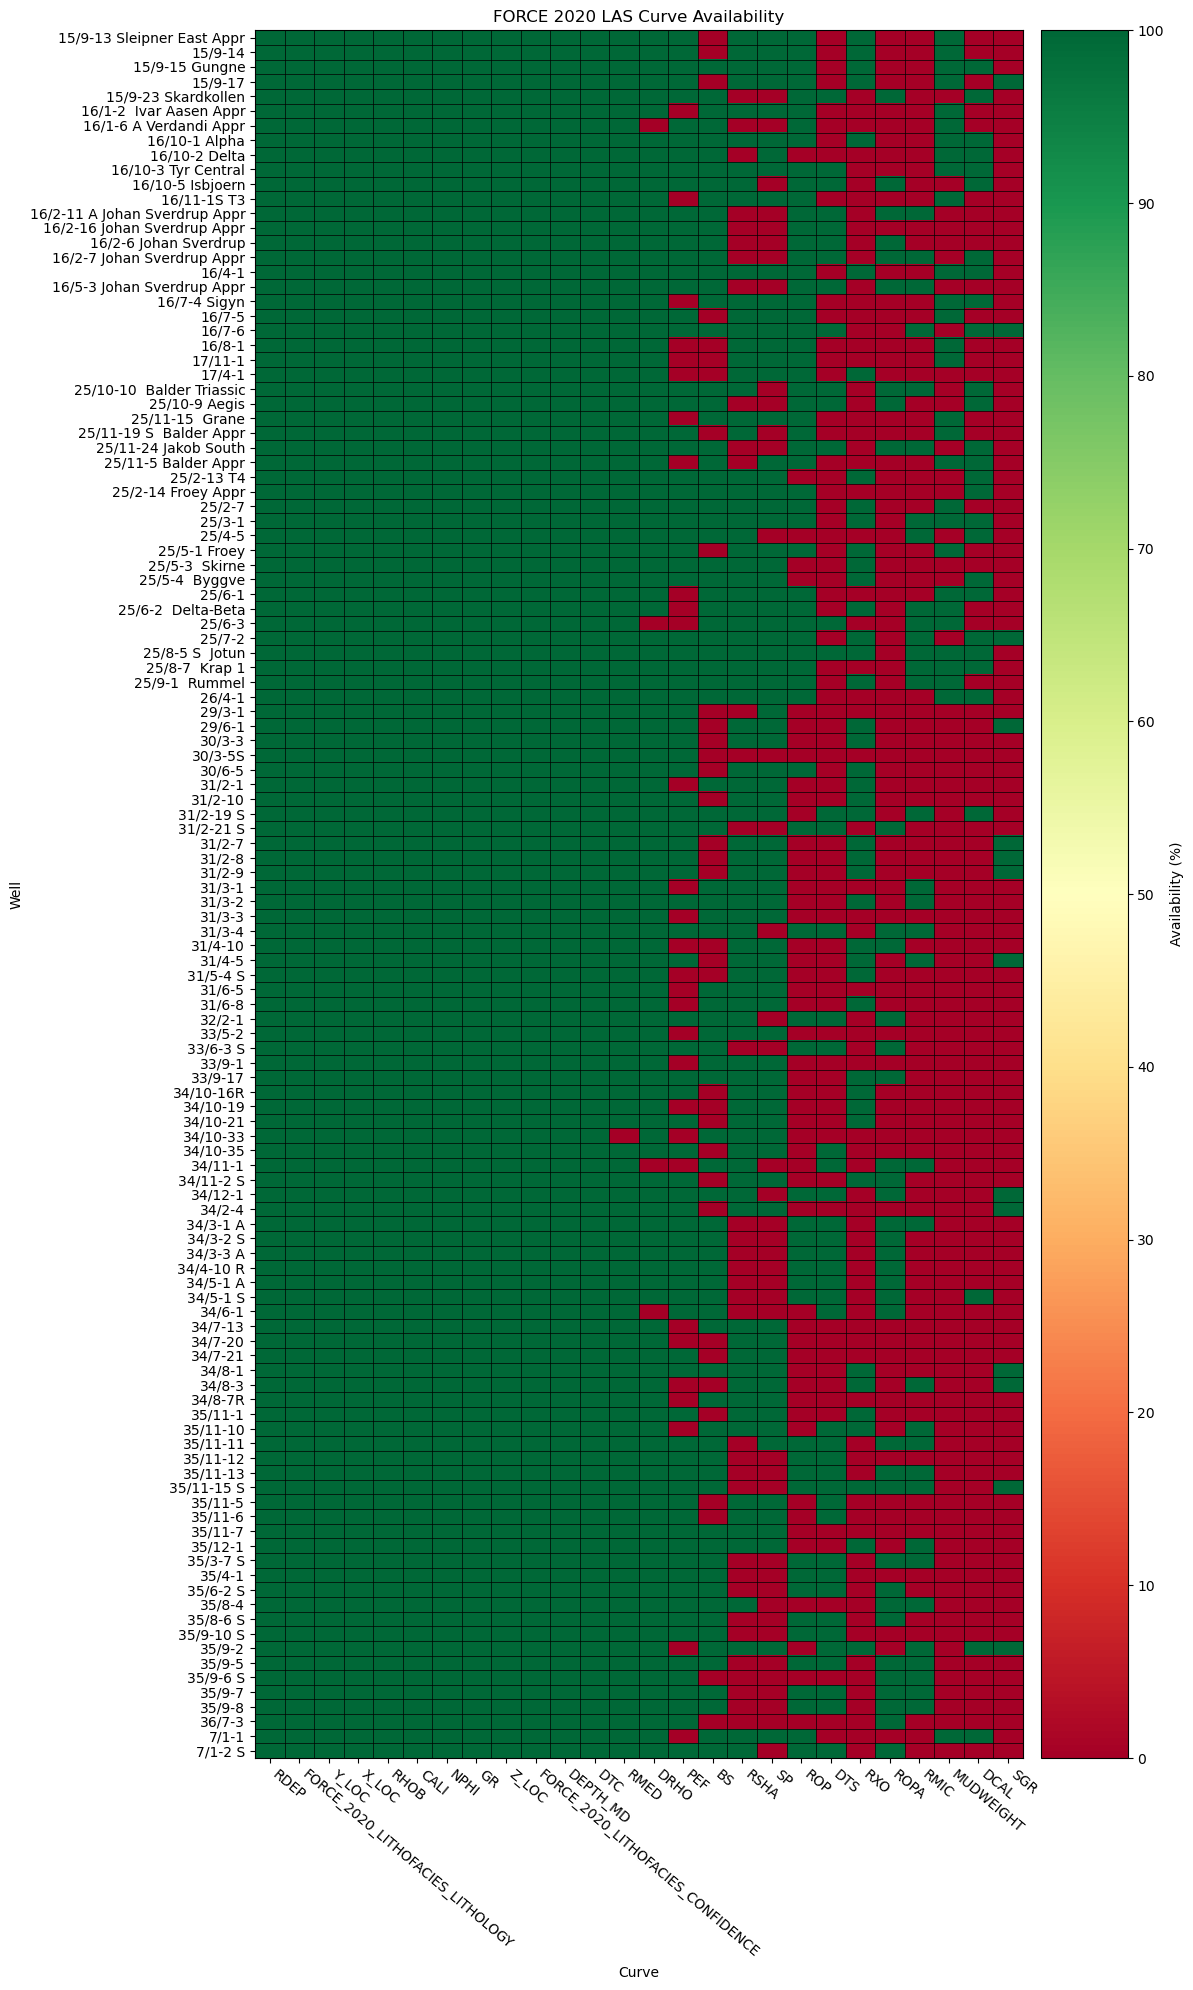

In [13]:
### plot presence

sorted_curves = (
    curve_presence
    .sum()
    .sort_values(ascending=False)
    .index
)

### reorder curve_presence columns using the sorted curve names
curve_presence_matrix = curve_presence[sorted_curves].astype(int)
### curve either 0 or 1 
plot_matrix(curve_presence_matrix)


In [14]:
# ### measure how valid each curve is for each well

# validity_matrix = (
#     curve_inventory
#     .pivot_table(
#         index="well",
#         columns="curve",
#         values="missing_pct",
#     )
# )

# sorted_curves = (
#     (100 - validity_matrix)
#     .sum()
#     .sort_values(ascending=False)
#     .index
# )

# ### reorder validity matrix columns using the sorted curve names
# validity_matrix = validity_matrix[sorted_curves]

# ### curve from 0 to 100
# plot_matrix(validity_matrix)

16_10-3.las

CURVES:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'BS', 'DCAL', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'SP', 'DTS', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']

STRT = 114.9095993 m | 
STOP = 2850.0324707 m | 
STEP = 0.152 m | 
NULL = -999.25  | 
COMP =   | COMPANY
WELL = 16/10-3 Tyr Central  | WELL
FLD =   | FIELD
LOC =   | LOCATION
SRVC =   | SERVICE COMPANY
DATE = 2020-08-09 20:01:14   : Log Export Date {yyyy-MM-dd HH:mm  | ss}
PROV =   | PROVINCE
UWI = 16/10-3  | UNIQUE WELL ID
API =   | API NUMBER

Unique location values:
   unique_x  unique_y     x_min     x_max      y_min      y_max
0      1404        20 460416.62 460460.47 6453743.00 6453752.50

Trajectory null values:
DEPTH_MD    0
X_LOC       0
Y_LOC       0
Z_FT        0
dtype: int64

Trajectory describe:
       DEPTH_MD     X_LOC      Y_LOC     Z_FT
count  17356.00  17356.00   17356.00 17356.00
mean    1528.43 460429.25 

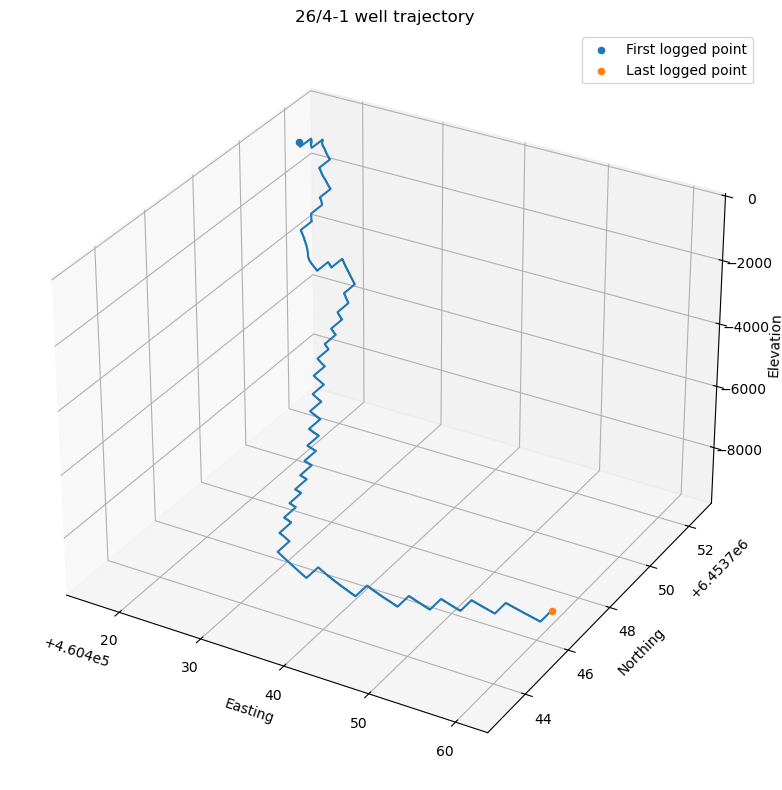

In [28]:
### inspect las file well trajectory

def inspect_las_trajectory(las_input):
    print(f'{os.path.basename(las_input)}\n')
    ### verbose output
    single_las = lasio.read(las_input)
    
    ### selected output
    curve_names = [curve.mnemonic for curve in single_las.curves]
    print(f'CURVES:\n{curve_names}\n')

    for item in single_las.well:
        print(
            item.mnemonic,
            "=",
            item.value,
            item.unit,
            "|",
            item.descr,
        )

    ### read as pandas df, if x and y coordinates exist print them
        ### x = easting, y = northing
    df = single_las.df()
    ### show depth in feet
    df["Z_FT"] = df["Z_LOC"] * FT_PER_M
    if 'X_LOC' in df.columns and df['X_LOC'].notna().any():

        xy_check = pd.DataFrame(
            {
                "unique_x": [df["X_LOC"].nunique(dropna=True)],
                "unique_y": [df["Y_LOC"].nunique(dropna=True)],
                "x_min": [df["X_LOC"].min()],
                "x_max": [df["X_LOC"].max()],
                "y_min": [df["Y_LOC"].min()],
                "y_max": [df["Y_LOC"].max()],
            }
        )
        print(f'\nUnique location values:\n{xy_check}\n')

        ### finding: some wells are deviated, not perfectly vertical and so there is a trajectory that varies spatially, measured depth = depth along borehole
        trajectory = df[["DEPTH_MD", 
                         "X_LOC", 
                         "Y_LOC", 
                        #  "Z_LOC",
                         "Z_FT",
                         ]].dropna().copy()
        print(f'Trajectory null values:\n{trajectory.isna().sum()}') ,print(f'\nTrajectory describe:\n{trajectory.describe().round(2)}')

        first_point = trajectory.iloc[0]
        last_point = trajectory.iloc[-1]

        print(
        "\nFirst valid trajectory point"
        f"\nMD: {first_point['DEPTH_MD']:.2f}"
        f"\nX:  {first_point['X_LOC']:.2f}"
        f"\nY:  {first_point['Y_LOC']:.2f}"
        # f"\nZ:  {first_point['Z_LOC']:.2f}"
        f"\nZ:  {first_point['Z_FT']:.2f}"
        )

        print(
        "\nLast valid trajectory point"
        f"\nMD: {last_point['DEPTH_MD']:.2f}"
        f"\nX:  {last_point['X_LOC']:.2f}"
        f"\nY:  {last_point['Y_LOC']:.2f}"
        # f"\nZ:  {last_point['Z_LOC']:.2f}"
        f"\nZ:  {last_point['Z_FT']:.2f}"
        )

        ### 3d plot
        fig = plt.figure(figsize=(9, 8))
        ax = fig.add_subplot(111, projection="3d")

        ax.plot(
            trajectory["X_LOC"],
            trajectory["Y_LOC"],
            # trajectory["Z_LOC"],
            trajectory["Z_FT"],
        )

        ax.scatter(
            trajectory["X_LOC"].iloc[0],
            trajectory["Y_LOC"].iloc[0],
            # trajectory["Z_LOC"].iloc[0],
            trajectory["Z_FT"].iloc[0],
            label="First logged point",
        )

        ax.scatter(
            trajectory["X_LOC"].iloc[-1],
            trajectory["Y_LOC"].iloc[-1],
            # trajectory["Z_LOC"].iloc[-1],
            trajectory["Z_FT"].iloc[-1],
            label="Last logged point",
        )

        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")
        ax.set_zlabel("Elevation")
        ax.set_title("26/4-1 well trajectory")
        ax.legend()

        plt.tight_layout()
        plt.show()

    else:
        print("\nMISSING location curves")

### test with random las file
random_las = random.choice(LAS_FILES)
inspect_las_trajectory(random_las)

Wells: 118
Map extent: [0.8696971648891672, 5.081816957638773, 57.697152329674445, 62.2348775634949]


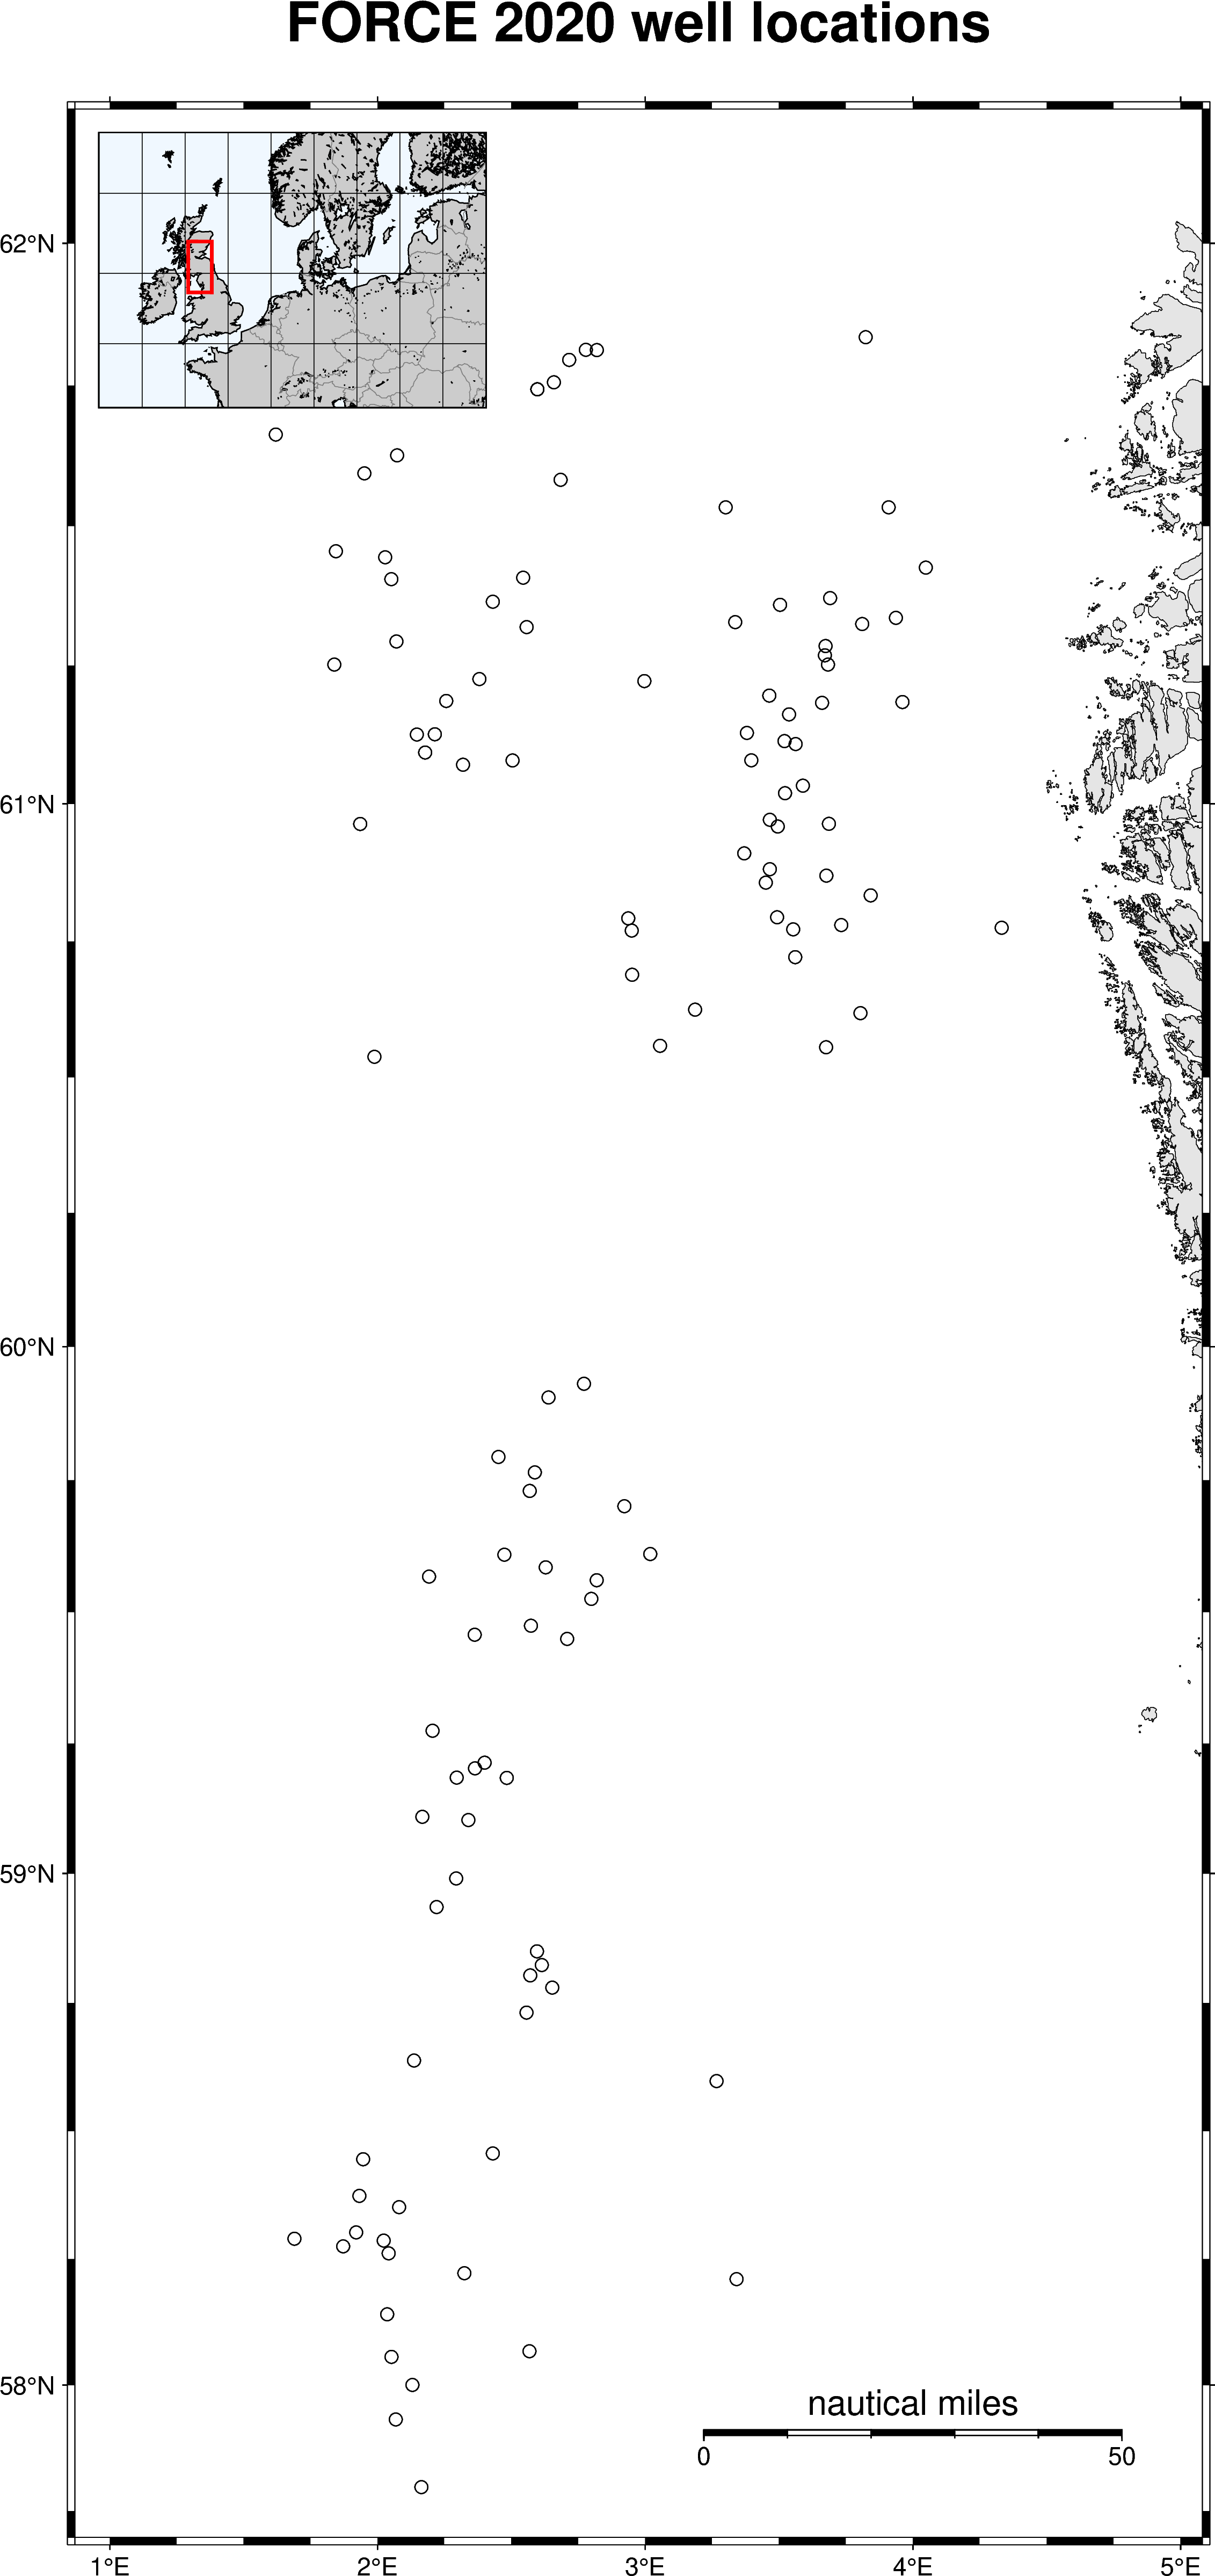

In [20]:
### make df to get only the shallowest records at wellhead for mapping
wellhead_records = []

for path in LAS_FILES:
    las = lasio.read(path)
    df = las.df()

    required = ["DEPTH_MD", "X_LOC", "Y_LOC", "Z_LOC"]

    if not all(column in df.columns for column in required):
        continue

    location = (
        df[required]
        .dropna()
        .sort_values("DEPTH_MD")
    )

    if location.empty:
        continue

    shallowest = location.iloc[0]

    try:
        well_name = str(las.well["WELL"].value)
    except (KeyError, AttributeError):
        well_name = path.stem

    wellhead_records.append(
        {
            "well": well_name,
            "file": path.name,
            "depth_md": shallowest["DEPTH_MD"],
            "easting": shallowest["X_LOC"],
            "northing": shallowest["Y_LOC"],
            "z": shallowest["Z_LOC"],
        }
    )

wellheads = pd.DataFrame(wellhead_records)
print("Wells:", len(wellheads))


### convert from projected coordinate reference system to lat/long for pygmt to ingest

source_crs = CRS.from_epsg(23031)
map_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(
    source_crs,
    map_crs,
    always_xy=True,
)

longitude, latitude = transformer.transform(
    wellheads["easting"].to_numpy(),
    wellheads["northing"].to_numpy(),
)

wellheads["longitude"] = longitude
wellheads["latitude"] = latitude

wellheads[
    ["well", "easting", "northing", "longitude", "latitude"]
].head()


### find the map extent for all the wells and pad with margins 

longitude_margin = 0.75
latitude_margin = 0.4

region = [
    wellheads["longitude"].min() - longitude_margin,
    wellheads["longitude"].max() + longitude_margin,
    wellheads["latitude"].min() - 0.1,
    wellheads["latitude"].max() + latitude_margin,
]

print(f'Map extent: {region}')



#### plot figure of all the wells

fig = pygmt.Figure()

fig.coast(
    region=region,
    projection="M7i",
    shorelines=True,
    borders="1/0.5p,black",  ### level 1 = national boundaries
    land="gray90",
    water="white",
    frame=["af", "+tFORCE 2020 well locations"],
    ### nautical mile scale bar:
    ### L: specifies a map scale
    ### g<lon>/<lat>: anchor point for scale calculation
    ### +c<lat>: origin latitude where scale is exact
    ### +w<length>N: scale bar width in nautical miles (n = Nautical Miles)
    ### +f: gives scale bar style
    ### +l: adds a label (optional)
    map_scale="g4.0/57.9+c57.9+w50n+f+l",
)

fig.plot(
    x=wellheads["longitude"],
    y=wellheads["latitude"],
    style="c0.08i",
    pen="0.5p",
)

### add Europe inset map
###   jTL = j (inside main map) T (top) L (left)
###   +w2.4i/1.7i = inset size (width 2.4 in, height 1.7 in)
###   +o0.15i/0.15i = offset from border
###   plot Europe overview map
with fig.inset(
    position="jTL+w2.4i/1.7i+o0.15i/0.15i",
    box="+gwhite+p1p,black",
):
    fig.coast(
        region=[-15, 30, 45, 70],
        projection="M2.4i",
        land="gray80",
        water="aliceblue",
        borders="1/0.25p,gray50",
        shorelines="0.5p,black",
        frame="g",
    )
    ### Highlight main map boundary inside the inset
    fig.plot(
        x=[region[0], region[1], region[1], region[0], region[0]],
        y=[region[2], region[2], region[3], region[3], region[2]],
        pen="1.5p,red",
    )

fig.show()

In [25]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)